# Comparing four SAXS reweighters: BME, iBME, BMECustom and COPER

The other notebooks each used one reweighter. Here we put all four side by side on the
*same* STARLING ensemble and the *same* experimental SAXS curve, and ask: **do they produce
the same reweighted ensemble?**

| method | family | how the SAXS scale is handled |
|--------|--------|-------------------------------|
| `BME` | penalty (`cost + θ·D_KL`) | fixed pre-scale (set once from the prior) |
| `iBME` | penalty, iterative | **fitted** (alternates scale/offset with BME) |
| `BMECustom` | penalty, custom cost | **marginalised** inside the cost at every step |
| `COPER` | hard `χ² ≤ limit` constraint | fixed pre-scale (set once from the prior) |

The reweighters parameterise their strength differently (`θ` vs `χ²` limit), so to compare
them fairly we tune each to a **common effective sample size** `φ ≈ 0.6` (retain ~60% of the
ensemble) and then compare the ensembles they select.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import glob
import itertools

import numpy as np
import matplotlib.pyplot as plt

from soursop.ssbme import BME, iBME, BMECustom, ExperimentalObservable
from soursop.sscoper import COPER
from soursop.sstrajectory import SSTrajectory

DATA_DIR = Path(".")
SAXS_FRAME_DIR = DATA_DIR / "saxs_frames"

## 1. Load data, define the common fit metric

We load the experimental curve, the per-frame computed profiles, and the per-frame Rg. To
score every method on an equal footing we use a single **scale-marginalised reduced χ²**
(re-optimising the overall SAXS scale for whatever weights we are scoring), regardless of how
each method treated the scale internally.

In [2]:
exp = np.loadtxt(DATA_DIR / "pnt.dat")
q_exp, I_exp_raw, sigma_exp_raw = exp[:, 0], exp[:, 1], exp[:, 2]
frame_files = sorted(glob.glob(str(SAXS_FRAME_DIR / "frame_*.dat")))
q_calc = np.loadtxt(frame_files[0])[:, 0]
calc = np.array([np.loadtxt(f)[:, 1] for f in frame_files])
n_frames = calc.shape[0]

mask = (q_calc >= q_exp.min()) & (q_calc <= q_exp.max())
q = q_calc[mask]
I_exp = np.interp(q, q_exp, I_exp_raw)
sigma_exp = np.interp(q, q_exp, sigma_exp_raw)
C = calc[:, mask]                       # raw per-frame computed curves (n_frames, m)


def optimal_scale(avg):
    return np.sum(avg * I_exp / sigma_exp**2) / np.sum(avg**2 / sigma_exp**2)


def curve_chi2(weights):
    """Scale-marginalised reduced chi^2 (the common scoring metric)."""
    avg = weights @ C
    return float(np.mean(((optimal_scale(avg) * avg - I_exp) / sigma_exp) ** 2))


# pre-scaled copy for the methods that compare values directly (BME, COPER)
C_scaled = optimal_scale(C.mean(axis=0)) * C
observables = [ExperimentalObservable(I_exp[k], sigma_exp[k]) for k in range(q.size)]

protein = SSTrajectory(str(DATA_DIR / "pnt_STARLING.xtc"),
                       str(DATA_DIR / "pnt_STARLING.pdb")).proteinTrajectoryList[0]
rg = protein.get_radius_of_gyration()
print(f"{n_frames} conformers, {q.size} q-points; prior <Rg> = {rg.mean():.2f} A")

600 conformers, 76 q-points; prior <Rg> = 57.10 A


## 2. Tune each method to a common effective sample size

`φ = exp(-D_KL(w‖w0))` increases monotonically with the penalty `θ` (and with COPER's `χ²`
limit), so a simple bisection finds the knob value that yields `φ ≈ 0.6` for each method.

In [3]:
TARGET_PHI = 0.6


def bisect_knob(fit_at, lo, hi, n_steps=18):
    """Find the knob value in [lo, hi] whose fit has phi ~ TARGET_PHI."""
    for _ in range(n_steps):
        mid = np.sqrt(lo * hi)
        if fit_at(mid).phi < TARGET_PHI:
            lo = mid          # too much reweighting -> raise the knob
        else:
            hi = mid
    return np.sqrt(lo * hi)


fit_bme = lambda t: BME(observables, C_scaled).fit(theta=t, auto_theta=False, verbose=False)
fit_ibme = lambda t: iBME(observables, C).fit(theta=t, verbose=False)
fit_custom = lambda t: BMECustom(I_exp, C, cost_function=lambda e, c, w: curve_chi2(w)).fit(theta=t, verbose=False)
fit_coper = lambda L: COPER(observables, C_scaled).fit(chi2_limit=L, verbose=False)

results = {
    "BME (prescaled)":   fit_bme(bisect_knob(fit_bme, 0.5, 2000.0)),
    "iBME (fits scale)": fit_ibme(bisect_knob(fit_ibme, 0.5, 2000.0)),
    "BMECustom (curve)": fit_custom(bisect_knob(fit_custom, 0.05, 100.0)),
    "COPER (prescaled)": fit_coper(bisect_knob(fit_coper, 0.8, 4.0)),
}
print("tuned all four to phi ~ %.2f" % TARGET_PHI)

tuned all four to phi ~ 0.60


## 3. Summary table

At matched `φ`, compare the mean Rg each method lands on and how well each reproduces the raw
scattering (common scale-marginalised χ²).

In [4]:
print(f"{'method':<20}{'<Rg> (A)':>10}{'phi':>7}{'curve chi2':>13}")
print("-" * 50)
print(f"{'prior (uniform)':<20}{rg.mean():>10.2f}{1.0:>7.2f}{curve_chi2(np.full(n_frames, 1/n_frames)):>13.2f}")
for name, r in results.items():
    print(f"{name:<20}{r.weights @ rg:>10.2f}{r.phi:>7.2f}{curve_chi2(r.weights):>13.2f}")

method                <Rg> (A)    phi   curve chi2
--------------------------------------------------
prior (uniform)          57.10   1.00         4.40
BME (prescaled)          56.20   0.60         1.39
iBME (fits scale)        58.33   0.60         1.57
BMECustom (curve)        51.40   0.60         0.76
COPER (prescaled)        56.20   0.60         1.39


## 4. Do they fit the curve the same way, and pick the same sizes?

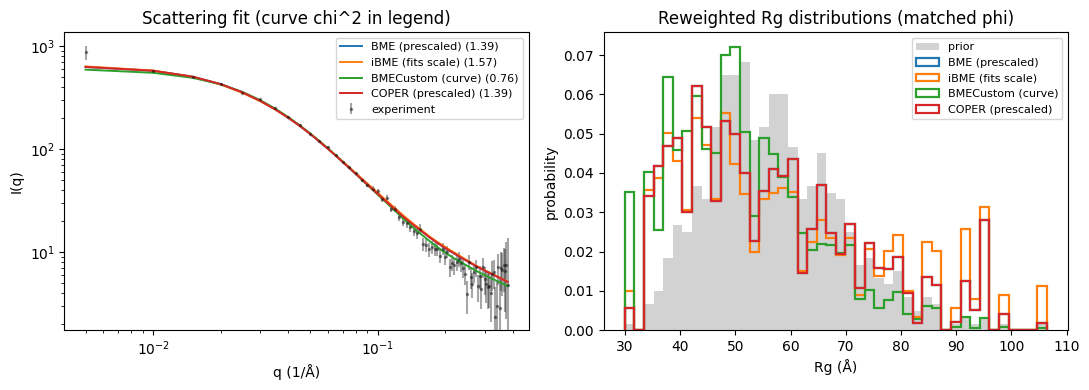

In [5]:
colors = {"BME (prescaled)": "C0", "iBME (fits scale)": "C1",
          "BMECustom (curve)": "C2", "COPER (prescaled)": "C3"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))

# left: scattering fits
axL.errorbar(q, I_exp, yerr=sigma_exp, fmt="k.", ms=3, alpha=0.35, label="experiment")
for name, r in results.items():
    avg = r.weights @ C
    axL.plot(q, optimal_scale(avg) * avg, color=colors[name], lw=1.4,
             label=f"{name} ({curve_chi2(r.weights):.2f})")
axL.set_xscale("log"); axL.set_yscale("log")
axL.set_xlabel("q (1/\u00c5)"); axL.set_ylabel("I(q)")
axL.set_title("Scattering fit (curve chi^2 in legend)")
axL.legend(fontsize=8)

# right: Rg distributions
bins = np.linspace(rg.min(), rg.max(), 45)
axR.hist(rg, bins=bins, weights=np.full(n_frames, 1/n_frames), color="gray", alpha=0.35, label="prior")
for name, r in results.items():
    axR.hist(rg, bins=bins, weights=r.weights, histtype="step", lw=1.6, color=colors[name], label=name)
axR.set_xlabel("Rg (\u00c5)"); axR.set_ylabel("probability")
axR.set_title("Reweighted Rg distributions (matched phi)")
axR.legend(fontsize=8)
fig.tight_layout()

## 5. Do the methods agree conformer-by-conformer?

The strongest test of agreement is whether the methods up- and down-weight the *same*
conformers. The Pearson correlation between each pair of weight vectors makes this explicit.

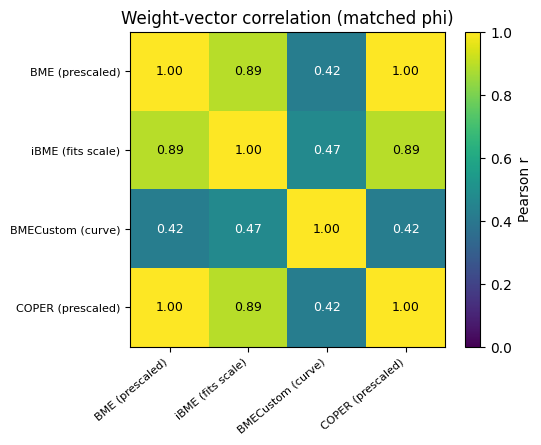

In [6]:
names = list(results.keys())
W = np.array([results[n].weights for n in names])
corr = np.corrcoef(W)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                color="white" if corr[i, j] < 0.7 else "black", fontsize=9)
ax.set_title("Weight-vector correlation (matched phi)")
fig.colorbar(im, label="Pearson r")
fig.tight_layout()

## 6. What we learn

At a matched effective sample size, two clear messages emerge (your exact numbers will track
the tables/figures above):

- **BME and COPER give the *same* ensemble** (weight correlation ≈ 1.0, identical ⟨Rg⟩ and
  χ²). That is expected: the penalty form (BME) and the hard-constraint form (COPER) are two
  ways of moving along the *same* maximum-entropy trade-off curve. Pick whichever is more
  convenient to specify — a penalty `θ`, or a target `χ²` with an explicit feasibility test.
- **How you treat the SAXS scale matters more than which algorithm you pick.** The methods
  that share a scale treatment cluster together; the ones that fit (`iBME`) or marginalise
  (`BMECustom`) the scale select a visibly different ensemble and a different ⟨Rg⟩.
  `BMECustom`, which re-optimises the scale against the full curve at every step, reaches the
  best curve χ² and the most compact ⟨Rg⟩.

**Practical guidance.**
- Use **`BMECustom`** when you have the raw curve and an uncertain scale (or want a bespoke
  goodness-of-fit); it uses the most information.
- Use **`iBME`** for the classic SAXS workflow where the scale (and a constant offset) should
  be fitted alongside the weights.
- Use **`BME`** when the observables are already on a known, common scale (e.g. Rg, NOE,
  chemical shifts), or **`COPER`** when you would rather state the target fit directly and be
  told whether it is even achievable.
- Always compare methods at matched `φ` (or matched χ²), never at matched `θ`/limit — the
  penalty has a different meaning for each method.